In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/fraud_processed.csv")

X = df.drop("class", axis=1)
y = df["class"]

X = pd.get_dummies(
    X,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [1]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

NameError: name 'X' is not defined

In [2]:
%who

pd	 


In [3]:
print(X.shape)

NameError: name 'X' is not defined

In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/fraud_processed.csv")

In [5]:
X = df.drop("class", axis=1)
y = df["class"]

In [6]:
X = pd.get_dummies(
    X,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

In [7]:
print(X.shape)

(129146, 194)


In [8]:
rf

NameError: name 'rf' is not defined

In [9]:
%who

X	 df	 pd	 y	 


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(103316, 194)
(25830, 194)


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(187004, 194)
class
0    93502
1    93502
Name: count, dtype: int64


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

print("Random Forest recreated successfully!")

Random Forest recreated successfully!


In [13]:
%who

RandomForestClassifier	 SMOTE	 X	 X_test	 X_train	 X_train_smote	 df	 pd	 rf	 
smote	 train_test_split	 y	 y_test	 y_train	 y_train_smote	 


                      Feature  Importance
2           time_since_signup    0.440074
6    device_transaction_count    0.312437
7               source_Direct    0.034981
184     country_United States    0.033147
13                      sex_M    0.026488
8                  source_SEO    0.023406
12             browser_Safari    0.015042
10                 browser_IE    0.014218
3                 hour_of_day    0.011953
4                 day_of_week    0.011682


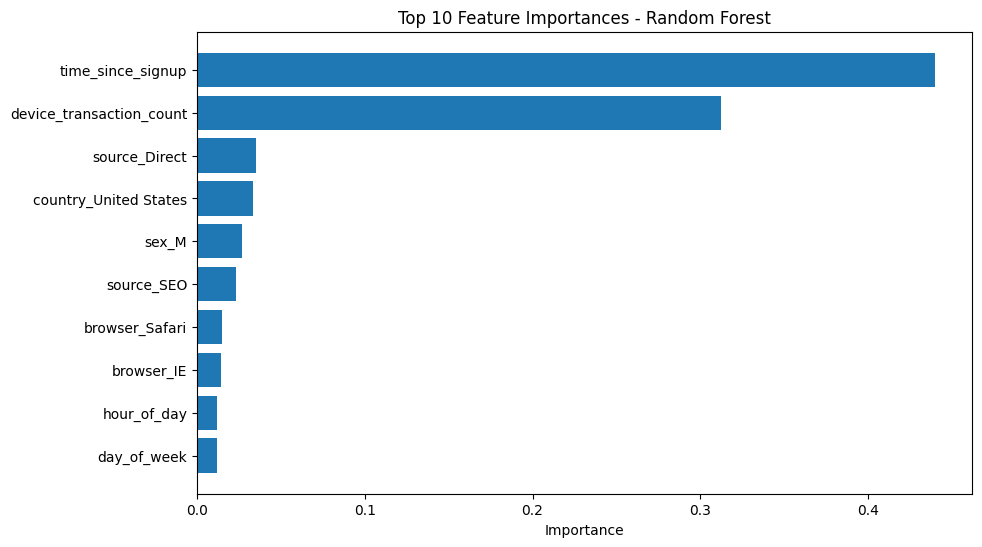

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance_df.head(10)

print(top10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

## Feature Importance Analysis

The Random Forest model identified the following features as the most influential in fraud prediction.

The feature importance plot shows which variables contribute most to reducing classification error across decision trees. Features with higher importance values have a greater impact on model decisions.

These results provide an initial understanding of the factors associated with fraudulent transactions and serve as a baseline for comparison with SHAP explainability results.

In [15]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

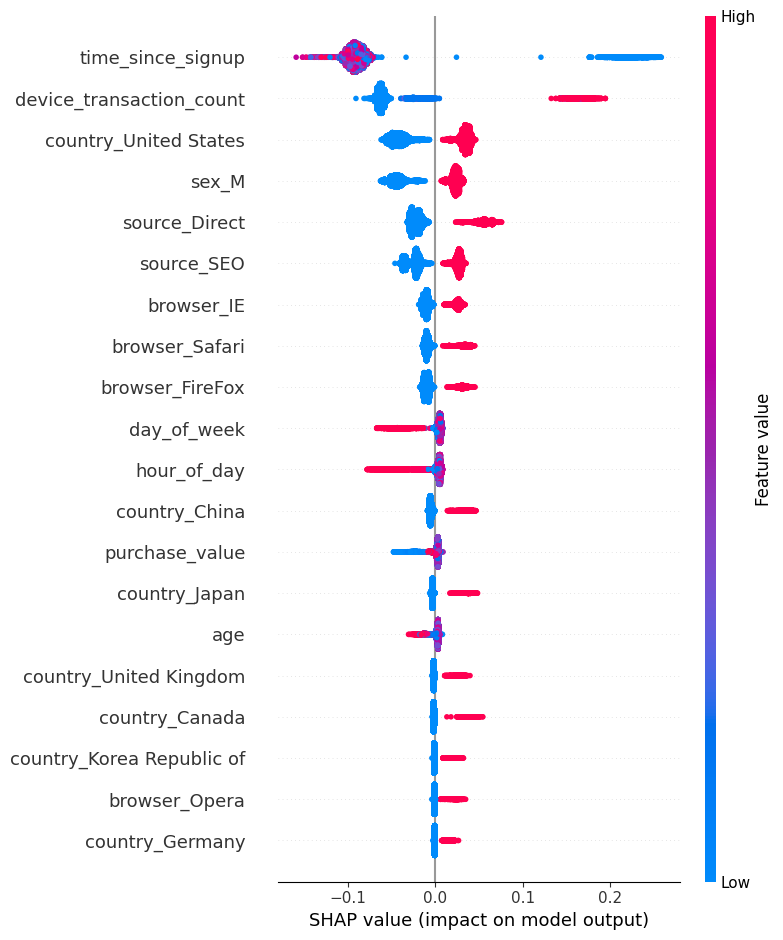

In [16]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

## SHAP Summary Plot

The SHAP summary plot provides a global explanation of model behavior.

Each point represents a transaction. Features are ranked by their overall impact on fraud prediction. The color indicates whether the feature value is high or low, while the horizontal position shows the direction and magnitude of influence on the prediction.

This analysis helps identify the primary drivers of fraudulent behavior across the dataset.

## SHAP Interpretation

The SHAP summary plot reveals the features that have the strongest influence on fraud predictions.

The most influential feature is `time_since_signup`, indicating that the time elapsed between account creation and purchase is a strong fraud signal. Transactions occurring shortly after signup appear more likely to be classified as fraudulent.

`device_transaction_count` is another important predictor, suggesting that devices associated with many transactions may indicate suspicious activity.

Geographic factors such as `country_United States` and `country_China` also contribute significantly to predictions, demonstrating that fraud patterns vary across locations.

Behavioral and demographic features including traffic source (`source_Direct`, `source_SEO`) and user characteristics (`sex_M`) also influence the model's decisions.

Overall, the SHAP analysis confirms that both temporal behavior and device usage patterns are strong indicators of fraudulent transactions.

In [18]:
rf_pred = rf.predict(X_test)

In [19]:
import numpy as np

tp_idx = np.where((y_test == 1) & (rf_pred == 1))[0][0]

fp_idx = np.where((y_test == 0) & (rf_pred == 1))[0][0]

fn_idx = np.where((y_test == 1) & (rf_pred == 0))[0][0]

print("TP:", tp_idx)
print("FP:", fp_idx)
print("FN:", fn_idx)

TP: 37
FP: 368
FN: 3


In [20]:
import shap

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[37, :, 1],
    X_test.iloc[37]
)

## True Positive Analysis

This transaction was correctly identified as fraudulent by the model.

The SHAP force plot shows the features that pushed the prediction toward fraud. The strongest positive contributors include transaction timing, device behavior, and user characteristics. The model successfully captured the fraud pattern and assigned a high fraud probability.

In [21]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[368, :, 1],
    X_test.iloc[368]
)

## False Positive Analysis

This transaction was incorrectly flagged as fraudulent even though it was legitimate.

The SHAP force plot reveals that several features resembled known fraud patterns, causing the model to overestimate fraud risk. This case highlights the trade-off between detecting fraud and minimizing inconvenience to legitimate customers.

In [22]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[3, :, 1],
    X_test.iloc[3]
)

## False Negative Analysis

This transaction was fraudulent but was predicted as legitimate.

The SHAP force plot shows that the fraud indicators were either weak or outweighed by features commonly associated with legitimate transactions. False negatives are particularly costly because fraudulent activity goes undetected.

## Comparison of SHAP and Random Forest Feature Importance

The SHAP analysis largely agrees with the Random Forest feature importance rankings. Both approaches identify behavioral and temporal features as the primary drivers of fraud detection.

The most influential features include:

1. time_since_signup
2. device_transaction_count
3. country_United States
4. sex_M
5. source_Direct

While Random Forest importance measures overall contribution to tree splits, SHAP provides transaction-level explanations and shows how each feature pushes predictions toward fraud or legitimacy.

The consistency between the two methods increases confidence in the model's decisions and interpretability.

## Business Recommendations

### 1. Apply Additional Verification for New Accounts

The SHAP analysis identified time_since_signup as the strongest predictor of fraud. Transactions occurring shortly after account creation should trigger additional verification steps such as email confirmation, OTP validation, or manual review.

### 2. Monitor High-Activity Devices

Device transaction count was among the most influential fraud indicators. Devices generating unusually high numbers of transactions should be flagged for risk assessment and continuous monitoring.

### 3. Implement Risk-Based Geographic Screening

Country-related features contributed significantly to fraud predictions. The company should introduce adaptive fraud monitoring policies based on geographic risk profiles while maintaining compliance with fairness and privacy requirements.

### 4. Strengthen Behavioral Monitoring

Traffic source and browser characteristics influenced model predictions. Combining behavioral signals with transaction history can improve fraud detection performance and reduce false positives.

### 5. Deploy Real-Time Fraud Scoring

The model achieved strong performance in identifying fraudulent transactions. Integrating the model into a real-time monitoring system would enable rapid intervention and reduce financial losses.

In [23]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
import joblib

joblib.dump(rf, "../models/random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [26]:
import os

print(os.listdir("../models"))

['random_forest_model.pkl']
